# Problem 11: Support Vector Regression (SVR) for Salary Prediction

**Objective**: Implement a Support Vector Regression (SVR) model to predict salary based on years of experience. Train the model and analyze the predicted values using regression metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic dataset
n_samples = 200
experience = np.random.uniform(1, 20, n_samples)
# Salary has non-linear relationship with experience (perfect for SVR)
salary = 30000 + (experience ** 1.3) * 5000 + np.random.normal(0, 5000, n_samples)

# Create DataFrame
df = pd.DataFrame({
    'experience': experience,
    'salary': salary
})

# Save to CSV
csv_path = 'salary_experience.csv'
df.to_csv(csv_path, index=False)
print(f"Dataset created: {csv_path}")
print(f"Dataset shape: {df.shape}")

Dataset created: salary_experience.csv
Dataset shape: (200, 2)


In [2]:
# Load and display dataset overview
df = pd.read_csv('salary_experience.csv')

print("Dataset Overview:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print(f"\nDataset Info:")
print(df.info())
print(f"\nDataset Statistics:")
print(df.describe())

Dataset Overview:
   experience         salary
0    8.116262  102655.774255
1   19.063572  261961.139504
2   14.907885  199118.175256
3   12.374511  158028.419886
4    3.964354   69292.485952

Dataset Shape: (200, 2)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   experience  200 non-null    float64
 1   salary      200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None

Dataset Statistics:
       experience         salary
count  200.000000     200.000000
mean    10.196118  138954.940141
std      5.602937   72392.075536
min      1.104920   32040.834425
25%      5.343066   74488.341168
50%     10.395239  132866.535095
75%     15.380333  202802.928210
max     19.750852  277689.604700


## Data Cleaning

Check for missing values, duplicates, and data type consistency.

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check data types
print(f"\nData types:")
print(df.dtypes)

# Remove any duplicates (if present)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

Missing values:
experience    0
salary        0
dtype: int64

Duplicate rows: 0

Data types:
experience    float64
salary        float64
dtype: object

Dataset shape after cleaning: (200, 2)


## Exploratory Data Analysis (EDA)

Visualize the relationship between experience and salary.

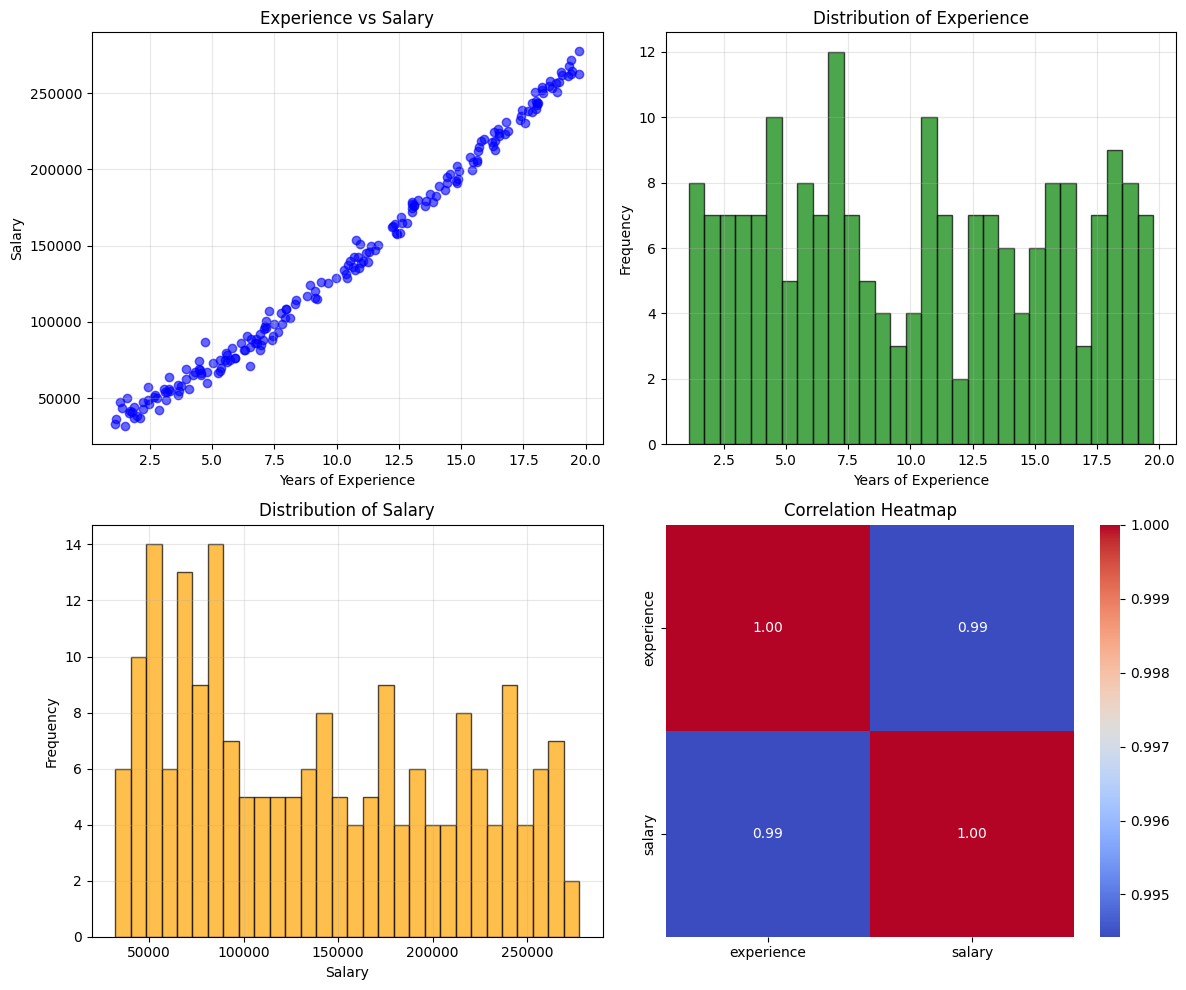

Correlation between experience and salary: 0.9944

Basic Statistics:
Experience range: 1.10 - 19.75 years
Salary range: $32040.83 - $277689.60


In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Scatter plot of experience vs salary
axes[0, 0].scatter(df['experience'], df['salary'], alpha=0.6, color='blue')
axes[0, 0].set_xlabel('Years of Experience')
axes[0, 0].set_ylabel('Salary')
axes[0, 0].set_title('Experience vs Salary')
axes[0, 0].grid(True, alpha=0.3)

# Distribution of experience
axes[0, 1].hist(df['experience'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Years of Experience')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Experience')
axes[0, 1].grid(True, alpha=0.3)

# Distribution of salary
axes[1, 0].hist(df['salary'], bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Salary')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Salary')
axes[1, 0].grid(True, alpha=0.3)

# Correlation heatmap
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

print(f"Correlation between experience and salary: {df['experience'].corr(df['salary']):.4f}")
print(f"\nBasic Statistics:")
print(f"Experience range: {df['experience'].min():.2f} - {df['experience'].max():.2f} years")
print(f"Salary range: ${df['salary'].min():.2f} - ${df['salary'].max():.2f}")

## Feature Scaling

Normalize the features using StandardScaler for optimal SVR performance.

In [5]:
# Separate features and target
X = df[['experience']].values
y = df['salary'].values

# Scale the features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scale the target for better SVR performance
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

print("Feature scaling completed")
print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y_scaled.shape}")
print(f"\nScaled feature statistics:")
print(f"X mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")
print(f"y mean: {y_scaled.mean():.4f}, std: {y_scaled.std():.4f}")

Feature scaling completed
X shape: (200, 1)
y shape: (200,)

Scaled feature statistics:
X mean: -0.0000, std: 1.0000
y mean: 0.0000, std: 1.0000


## Theory: Support Vector Regression (SVR)

**Support Vector Regression** is a regression algorithm that uses the principles of Support Vector Machines (SVM). 

Key concepts:
- **Margin of tolerance (epsilon)**: SVR finds a hyperplane that fits the data within an epsilon-tube
- **Support Vectors**: Data points that lie on or outside the epsilon-tube; these determine the regression function
- **Kernel trick**: Allows SVR to work in high-dimensional spaces without explicitly transforming the data
- **C parameter**: Controls the trade-off between fitting the training data and model complexity (regularization)

SVR can capture **non-linear relationships** in data, making it suitable for complex regression problems where linear regression may fail.

### Advantages:
- Effective in high-dimensional spaces
- Memory-efficient (uses only support vectors)
- Can model non-linear relationships via kernels
- Robust to outliers

### Disadvantages:
- Slower training than linear models
- Requires feature scaling
- Need to tune hyperparameters (C, epsilon, kernel)

## Mathematical Representation

SVR minimizes the following objective function:

$$\min \frac{1}{2}||w||^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$$

Subject to:
- $y_i - w^T \phi(x_i) - b \leq \epsilon + \xi_i$
- $w^T \phi(x_i) + b - y_i \leq \epsilon + \xi_i^*$
- $\xi_i, \xi_i^* \geq 0$

Where:
- $w$: weight vector
- $\phi(x)$: kernel function (maps input to higher dimension)
- $\epsilon$: margin of tolerance (epsilon-tube)
- $C$: regularization parameter
- $\xi_i, \xi_i^*$: slack variables (allow violations)
- $b$: bias term

**Prediction function**:
$$f(x) = w^T \phi(x) + b = \sum_{i=1}^{n} (\alpha_i - \alpha_i^*) K(x_i, x) + b$$

## Workflow Diagram

Visualize the complete SVR pipeline.

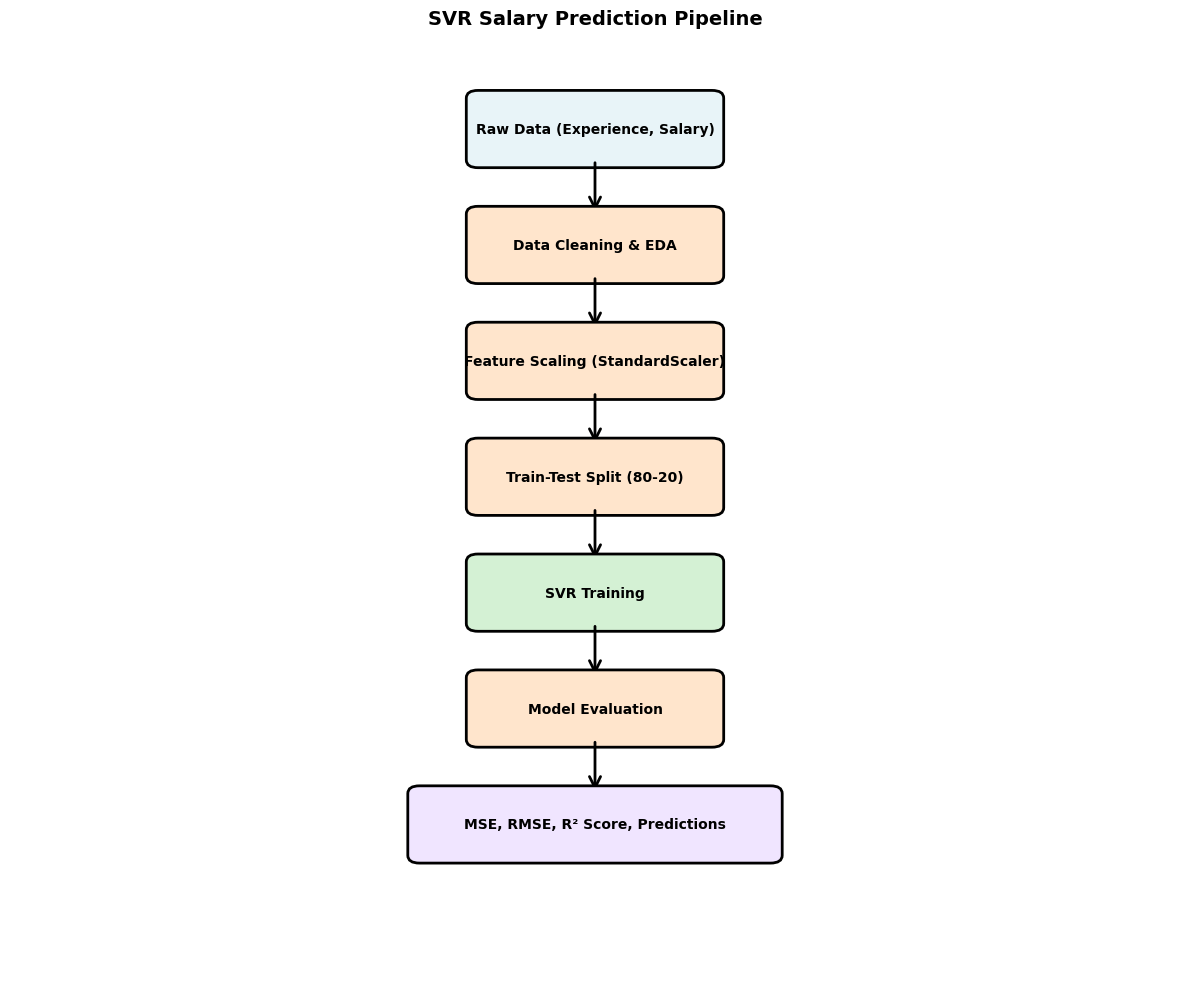

In [6]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Define colors
color_input = '#E8F4F8'
color_process = '#FFE5CC'
color_model = '#D4F1D4'
color_output = '#F0E5FF'

# Helper function to create boxes
def add_box(ax, x, y, width, height, text, color):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=10, weight='bold', wrap=True)

# Helper function to create arrows
def add_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20, 
                           linewidth=2, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.3, mid_y, label, fontsize=9, style='italic')

# Create workflow
add_box(ax, 5, 11, 2, 0.8, 'Raw Data (Experience, Salary)', color_input)
add_arrow(ax, 5, 10.6, 5, 9.9)

add_box(ax, 5, 9.5, 2, 0.8, 'Data Cleaning & EDA', color_process)
add_arrow(ax, 5, 9.1, 5, 8.4)

add_box(ax, 5, 8, 2, 0.8, 'Feature Scaling (StandardScaler)', color_process)
add_arrow(ax, 5, 7.6, 5, 6.9)

add_box(ax, 5, 6.5, 2, 0.8, 'Train-Test Split (80-20)', color_process)
add_arrow(ax, 5, 6.1, 5, 5.4)

add_box(ax, 5, 5, 2, 0.8, 'SVR Training', color_model)
add_arrow(ax, 5, 4.6, 5, 3.9)

add_box(ax, 5, 3.5, 2, 0.8, 'Model Evaluation', color_process)
add_arrow(ax, 5, 3.1, 5, 2.4)

add_box(ax, 5, 2, 3, 0.8, 'MSE, RMSE, R² Score, Predictions', color_output)

plt.title('SVR Salary Prediction Pipeline', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

## Pseudocode

```
ALGORITHM: Support Vector Regression
INPUT: Experience (X), Salary (y)

1. DATA PREPARATION
   - Load dataset (experience, salary)
   - Clean data: remove missing values and duplicates
   - Perform EDA: visualize relationships and distributions

2. FEATURE SCALING
   - Apply StandardScaler to X (experience)
   - Apply StandardScaler to y (salary)

3. TRAIN-TEST SPLIT
   - Split data: 80% training, 20% testing

4. SVR MODEL TRAINING
   - Initialize SVR with kernel='rbf', C=100, epsilon=0.1
   - Train on training data

5. PREDICTION
   - Predict on test set
   - Inverse scale predictions to original salary scale

6. EVALUATION
   - Calculate MSE: mean((y_true - y_pred)²)
   - Calculate RMSE: sqrt(MSE)
   - Calculate R²: 1 - (SS_res / SS_tot)
   - Visualize actual vs predicted values
   - Visualize residuals

7. MODEL PERSISTENCE
   - Save SVR model to joblib file
   - Save scaler to joblib file
```

## Train-Test Split

Split the data into training and testing sets.

In [7]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set shape: X_test {X_test.shape}, y_test {y_test.shape}")

Training set size: 160
Testing set size: 40

Training set shape: X_train (160, 1), y_train (160,)
Testing set shape: X_test (40, 1), y_test (40,)


## SVR Model Training

Train the Support Vector Regression model.

In [8]:
# Create and train SVR model
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train, y_train)

print("SVR Model trained successfully!")
print(f"\nModel Parameters:")
print(f"Kernel: {svr_model.kernel}")
print(f"C (regularization): {svr_model.C}")
print(f"Epsilon (margin): {svr_model.epsilon}")
print(f"Number of support vectors: {len(svr_model.support_vectors_)}")

SVR Model trained successfully!

Model Parameters:
Kernel: rbf
C (regularization): 100
Epsilon (margin): 0.1
Number of support vectors: 21


## Making Predictions

Generate predictions on the test set and inverse scale to original salary values.

In [9]:
# Make predictions on test set (scaled)
y_pred_scaled = svr_model.predict(X_test)

# Inverse scale predictions and actual values
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

print("Predictions made successfully!")
print(f"\nFirst 10 predictions:")
for i in range(min(10, len(y_pred))):
    print(f"Experience: {X_test[i][0]:.4f} (scaled) | Actual Salary: ${y_test_original[i]:.2f} | Predicted Salary: ${y_pred[i]:.2f}")

Predictions made successfully!

First 10 predictions:
Experience: 0.0333 (scaled) | Actual Salary: $131480.37 | Predicted Salary: $136441.00
Experience: -1.0219 (scaled) | Actual Salary: $74657.95 | Predicted Salary: $64744.49
Experience: 0.4200 (scaled) | Actual Salary: $158584.74 | Predicted Salary: $164793.42
Experience: -0.8376 (scaled) | Actual Salary: $74936.27 | Predicted Salary: $74040.37
Experience: -1.6218 (scaled) | Actual Salary: $36442.69 | Predicted Salary: $39923.14
Experience: 1.3172 (scaled) | Actual Salary: $230235.35 | Predicted Salary: $237684.85
Experience: 1.7096 (scaled) | Actual Salary: $262338.59 | Predicted Salary: $270792.55
Experience: 0.6580 (scaled) | Actual Salary: $178602.53 | Predicted Salary: $183891.91
Experience: 0.5479 (scaled) | Actual Salary: $179737.84 | Predicted Salary: $174917.45
Experience: 0.6069 (scaled) | Actual Salary: $179385.81 | Predicted Salary: $179705.77


## Evaluation Metrics

Calculate regression performance metrics.

In [10]:
# Calculate evaluation metrics on scaled data
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

# Calculate metrics on original scale
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred)

print("="*50)
print("SVR MODEL EVALUATION METRICS")
print("="*50)
print(f"\nMetrics (Scaled Data):")
print(f"  Mean Squared Error (MSE):    {mse_scaled:.6f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_scaled:.6f}")
print(f"  R² Score:                    {r2_scaled:.6f}")

print(f"\nMetrics (Original Scale - Salary):")
print(f"  Mean Squared Error (MSE):    ${mse:,.2f}")
print(f"  Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"  R² Score:                    {r2:.6f}")
print(f"\nModel explains {r2*100:.2f}% of the variance in salary")
print("="*50)

SVR MODEL EVALUATION METRICS

Metrics (Scaled Data):
  Mean Squared Error (MSE):    0.005519
  Root Mean Squared Error (RMSE): 0.074291
  R² Score:                    0.994327

Metrics (Original Scale - Salary):
  Mean Squared Error (MSE):    $28,779,448.22
  Root Mean Squared Error (RMSE): $5,364.65
  R² Score:                    0.994327

Model explains 99.43% of the variance in salary


## Actual vs Predicted Values

Visualize the actual vs predicted salary values.

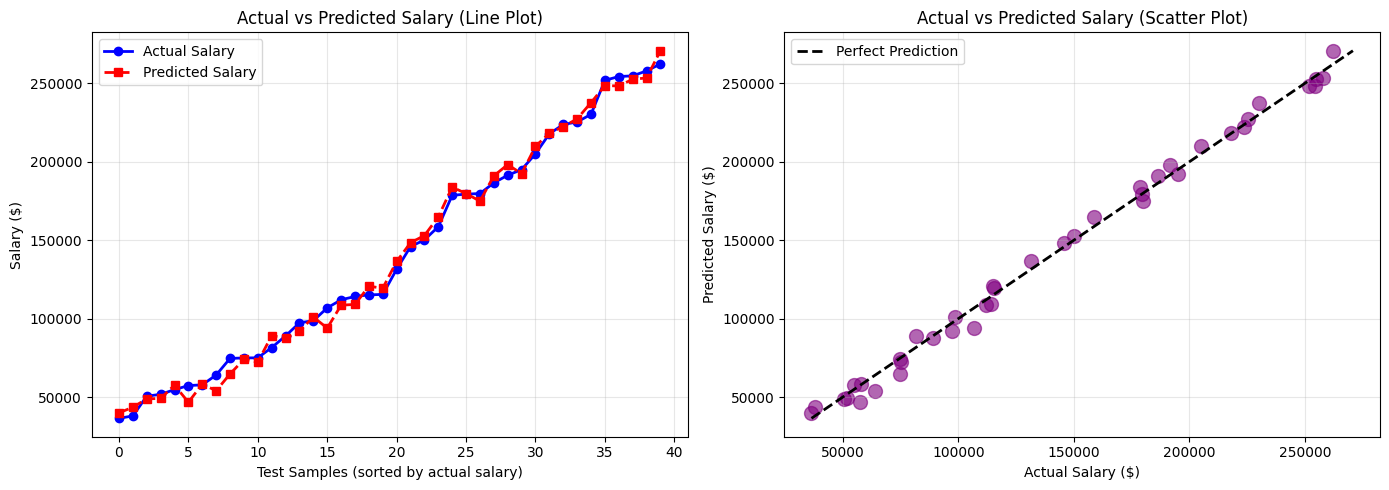


Actual Salary Range: $36,442.69 - $262,338.59
Predicted Salary Range: $39,923.14 - $270,792.55


In [11]:
# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by actual values for better visualization
sorted_indices = np.argsort(y_test_original)
sorted_actual = y_test_original[sorted_indices]
sorted_pred = y_pred[sorted_indices]
sorted_exp = scaler_X.inverse_transform(X_test[sorted_indices])

# Plot 1: Actual vs Predicted Line Plot
x_axis = np.arange(len(sorted_actual))
axes[0].plot(x_axis, sorted_actual, 'o-', label='Actual Salary', color='blue', linewidth=2, markersize=6)
axes[0].plot(x_axis, sorted_pred, 's--', label='Predicted Salary', color='red', linewidth=2, markersize=6)
axes[0].set_xlabel('Test Samples (sorted by actual salary)')
axes[0].set_ylabel('Salary ($)')
axes[0].set_title('Actual vs Predicted Salary (Line Plot)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Scatter Plot - Actual vs Predicted
axes[1].scatter(y_test_original, y_pred, alpha=0.6, color='purple', s=100)
# Add perfect prediction line
min_val = min(y_test_original.min(), y_pred.min())
max_val = max(y_test_original.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Salary ($)')
axes[1].set_ylabel('Predicted Salary ($)')
axes[1].set_title('Actual vs Predicted Salary (Scatter Plot)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nActual Salary Range: ${y_test_original.min():,.2f} - ${y_test_original.max():,.2f}")
print(f"Predicted Salary Range: ${y_pred.min():,.2f} - ${y_pred.max():,.2f}")

## Residuals Analysis

Analyze the prediction errors (residuals).

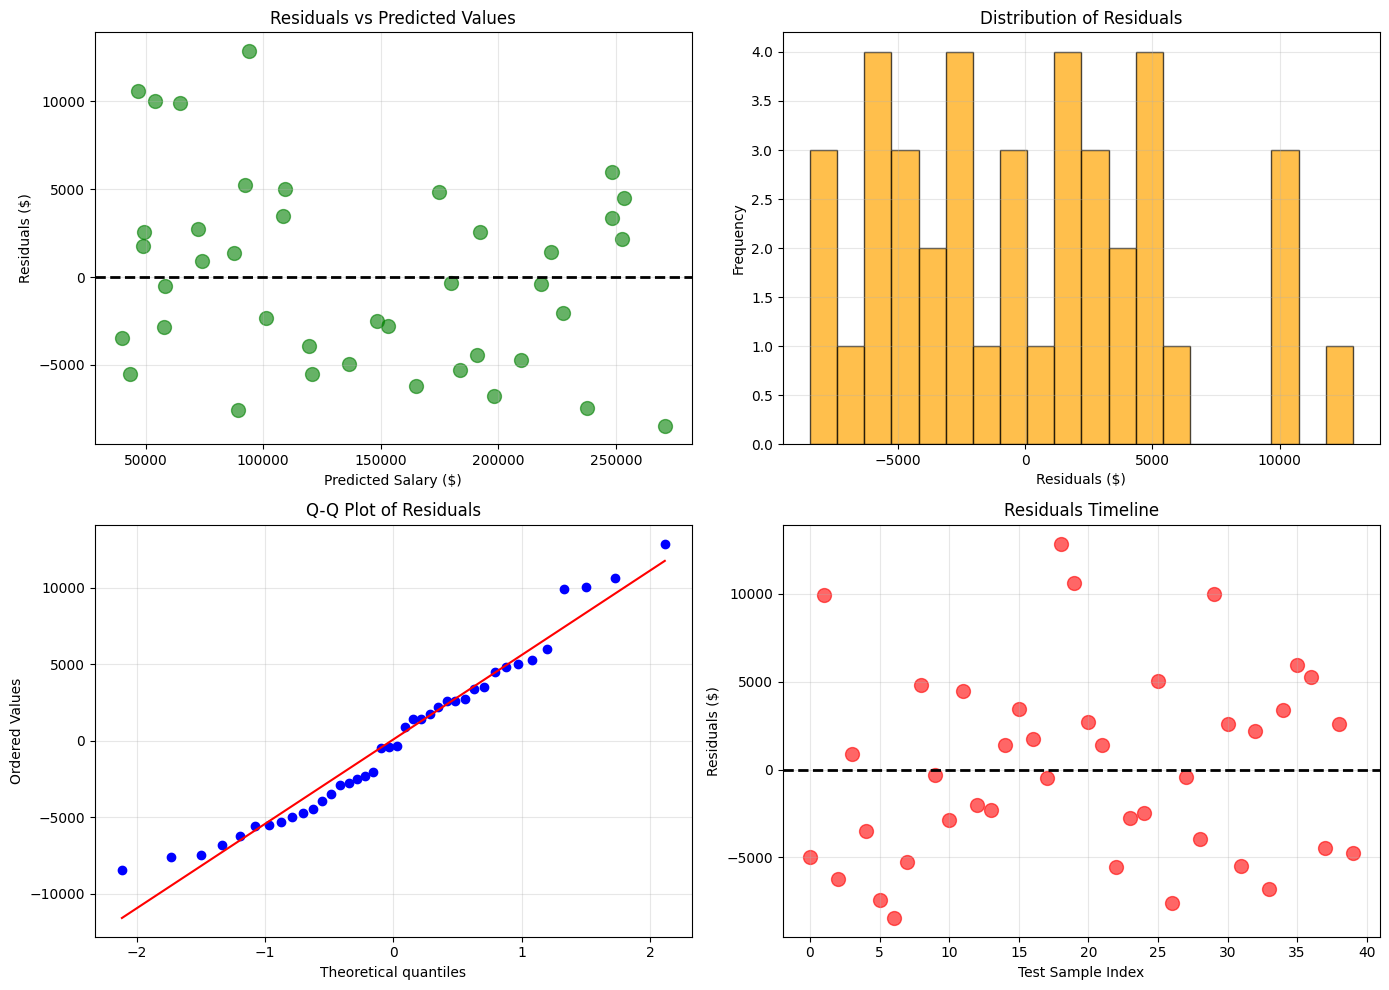


Residuals Statistics:
  Mean: $81.56
  Std Dev: $5,364.03
  Min: $-8,453.96
  Max: $12,871.22


In [12]:
# Calculate residuals
residuals = y_test_original - y_pred

# Create residuals visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Predicted Values
axes[0, 0].scatter(y_pred, residuals, alpha=0.6, color='green', s=100)
axes[0, 0].axhline(y=0, color='k', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Salary ($)')
axes[0, 0].set_ylabel('Residuals ($)')
axes[0, 0].set_title('Residuals vs Predicted Values')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals Distribution
axes[0, 1].hist(residuals, bins=20, color='orange', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Residuals ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Q-Q Plot (Normal Probability Plot)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals Timeline
axes[1, 1].scatter(np.arange(len(residuals)), residuals, alpha=0.6, color='red', s=100)
axes[1, 1].axhline(y=0, color='k', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Test Sample Index')
axes[1, 1].set_ylabel('Residuals ($)')
axes[1, 1].set_title('Residuals Timeline')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResiduals Statistics:")
print(f"  Mean: ${residuals.mean():,.2f}")
print(f"  Std Dev: ${residuals.std():,.2f}")
print(f"  Min: ${residuals.min():,.2f}")
print(f"  Max: ${residuals.max():,.2f}")

## Model Persistence and Prediction Example

Save the trained model and scaler, then demonstrate prediction on new data.

In [13]:
# Save the model and scalers
model_path = 'svr_salary_model.joblib'
scaler_x_path = 'scaler_X_salary.joblib'
scaler_y_path = 'scaler_y_salary.joblib'

joblib.dump(svr_model, model_path)
joblib.dump(scaler_X, scaler_x_path)
joblib.dump(scaler_y, scaler_y_path)

print(f"Model saved to: {model_path}")
print(f"X Scaler saved to: {scaler_x_path}")
print(f"y Scaler saved to: {scaler_y_path}")

# Example: Predict salary for new experience values
new_experience = np.array([[5], [10], [15]])
new_experience_scaled = scaler_X.transform(new_experience)
new_predictions_scaled = svr_model.predict(new_experience_scaled)
new_predictions = scaler_y.inverse_transform(new_predictions_scaled.reshape(-1, 1)).ravel()

print(f"\nExample Predictions for New Data:")
print("-" * 50)
for exp, pred in zip(new_experience, new_predictions):
    print(f"Experience: {exp[0]:.1f} years → Predicted Salary: ${pred:,.2f}")
print("-" * 50)

print("\n✓ SVR Salary Prediction Model completed successfully!")

Model saved to: svr_salary_model.joblib
X Scaler saved to: scaler_X_salary.joblib
y Scaler saved to: scaler_y_salary.joblib

Example Predictions for New Data:
--------------------------------------------------
Experience: 5.0 years → Predicted Salary: $69,298.35
Experience: 10.0 years → Predicted Salary: $131,433.86
Experience: 15.0 years → Predicted Salary: $200,378.35
--------------------------------------------------

✓ SVR Salary Prediction Model completed successfully!
